In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import csv
from collections import defaultdict
import numpy as np
from src.train import run_experiment

RUN_TRAINING = False

## Stałe pary vs nowe pary co epokę (wpis „Eksperyment: stałe pary vs nowe pary co epokę” w decyzje.md)

In [2]:
if RUN_TRAINING:
    for seed in [1, 2, 3]:
        run_experiment("stale_pary", seed, resample=False, augment=False, crop="bbox")
        run_experiment("nowe_pary", seed, resample=True, augment=False, crop="bbox")

stale_pary, seed 1: najlepsza epoka 2, EER test: wykwalifikowane 18.8%, losowe 15.4%
nowe_pary, seed 1: najlepsza epoka 5, EER test: wykwalifikowane 21.3%, losowe 16.7%
stale_pary, seed 2: najlepsza epoka 11, EER test: wykwalifikowane 24.5%, losowe 20.4%
nowe_pary, seed 2: najlepsza epoka 4, EER test: wykwalifikowane 28.6%, losowe 14.2%
stale_pary, seed 3: najlepsza epoka 4, EER test: wykwalifikowane 27.9%, losowe 13.8%
nowe_pary, seed 3: najlepsza epoka 10, EER test: wykwalifikowane 23.6%, losowe 17.5%


## Augmentacja (wpis „Eksperyment: augmentacja” w decyzje.md)

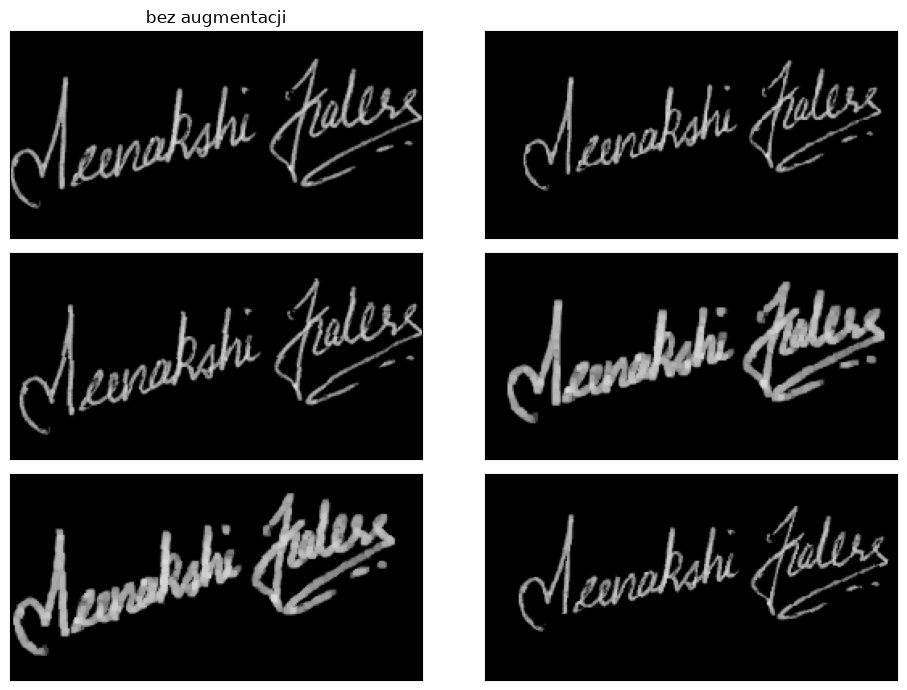

In [2]:
import random
import torch
import matplotlib.pyplot as plt
from src.dataset import SignaturePairs, make_augmentation

torch.manual_seed(0)
random.seed(0)
ds = SignaturePairs("train")
img = ds.images["original_30_5.png"]
aug = make_augmentation(thickness=True)

fig, axes = plt.subplots(3, 2, figsize=(10, 7))
axes.flat[0].imshow(img[0], cmap="gray", vmin=0, vmax=1)
axes.flat[0].set_title("bez augmentacji")
for ax in list(axes.flat)[1:]:
    ax.imshow(aug(img)[0], cmap="gray", vmin=0, vmax=1)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [3]:
if RUN_TRAINING:
    for seed in [1, 2, 3]:
        run_experiment("aug_geom", seed, augment=True, crop="bbox")
        run_experiment("aug_geom_grubosc", seed, augment=True, thickness=True, crop="bbox")

aug_geom, seed 1: najlepsza epoka 12, EER test: wykwalifikowane 17.9%, losowe 11.8%
aug_geom_grubosc, seed 1: najlepsza epoka 8, EER test: wykwalifikowane 20.4%, losowe 15.4%
aug_geom, seed 2: najlepsza epoka 9, EER test: wykwalifikowane 20.4%, losowe 11.2%
aug_geom_grubosc, seed 2: najlepsza epoka 11, EER test: wykwalifikowane 23.3%, losowe 12.1%
aug_geom, seed 3: najlepsza epoka 12, EER test: wykwalifikowane 22.5%, losowe 10.4%
aug_geom_grubosc, seed 3: najlepsza epoka 14, EER test: wykwalifikowane 25.3%, losowe 12.9%


## Wycieki: bez wyrównania atramentu, bez usuwania tła (wpis „Eksperyment: wycieki” w decyzje.md)

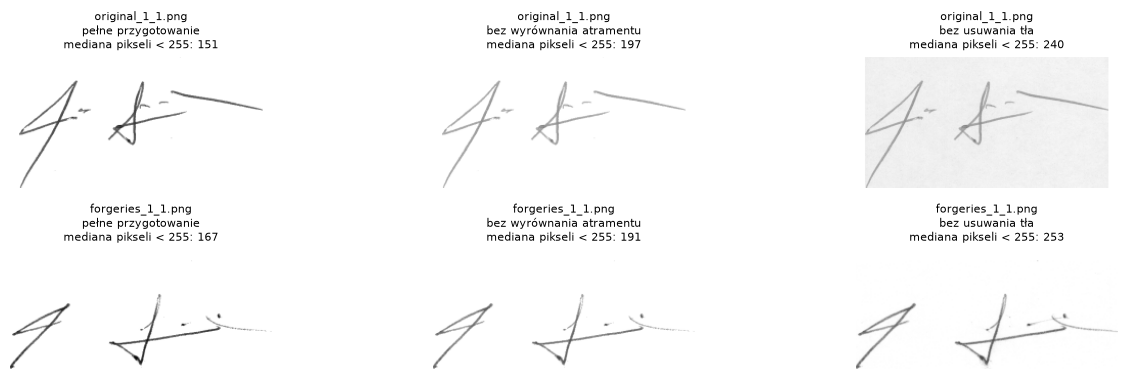

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import preprocess
from src.dataset import image_path

variants = [
    ("pełne przygotowanie", True, True),
    ("bez wyrównania atramentu", True, False),
    ("bez usuwania tła", False, False),
]
files = ["original_1_1.png", "forgeries_1_1.png"]

fig, axes = plt.subplots(len(files), len(variants), figsize=(13, 4))
for i, name in enumerate(files):
    for j, (title, background, ink) in enumerate(variants):
        img = preprocess(image_path(name), background=background, ink=ink)
        ink_pixels = img[img < 255]
        axes[i, j].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[i, j].set_title(f"{name}\n{title}\nmediana pikseli < 255: {np.median(ink_pixels):.0f}", fontsize=8)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

In [3]:
if RUN_TRAINING:
    for seed in [1, 2, 3]:
        run_experiment("bez_wyrownania_atramentu", seed, ink=False, crop="bbox")
        run_experiment("bez_usuwania_tla", seed, background=False, ink=False, crop="bbox")

bez_wyrownania_atramentu, seed 1: najlepsza epoka 22, EER test: wykwalifikowane 20.5%, losowe 13.3%
bez_usuwania_tla, seed 1: najlepsza epoka 24, EER test: wykwalifikowane 0.8%, losowe 12.6%
bez_wyrownania_atramentu, seed 2: najlepsza epoka 26, EER test: wykwalifikowane 21.7%, losowe 13.8%
bez_usuwania_tla, seed 2: najlepsza epoka 26, EER test: wykwalifikowane 2.5%, losowe 13.8%
bez_wyrownania_atramentu, seed 3: najlepsza epoka 27, EER test: wykwalifikowane 17.8%, losowe 10.8%
bez_usuwania_tla, seed 3: najlepsza epoka 19, EER test: wykwalifikowane 2.1%, losowe 15.8%


## Trening bez fałszerstw wykwalifikowanych (wpis „Eksperyment: trening bez fałszerstw wykwalifikowanych” w decyzje.md)

In [2]:
from collections import Counter
from src.dataset import ResampledPairs

check = ResampledPairs("train", skilled_per_writer=0, random_per_writer=48)
check.resample(1001)
print("pary:", len(check.pairs))
print("etykiety:", Counter(label for _, _, label in check.pairs))
print("pary z fałszerstwem:", sum("forgeries" in a or "forgeries" in b for a, b, _ in check.pairs))
print("pary losowe z tą samą osobą:", sum(
    a.split("_")[1] == b.split("_")[1] for a, b, label in check.pairs if label == 0.0))
del check

pary: 3360
etykiety: Counter({1.0: 1680, 0.0: 1680})
pary z fałszerstwem: 0
pary losowe z tą samą osobą: 0


In [3]:
if RUN_TRAINING:
    for seed in [1, 2, 3]:
        run_experiment("bez_wykw_trening", seed, skilled_train=False, crop="bbox")
        run_experiment("bez_wykw_wcale", seed, skilled_train=False, skilled_val=False, crop="bbox")

bez_wykw_trening, seed 1: najlepsza epoka 10, EER test: wykwalifikowane 24.9%, losowe 8.3%
bez_wykw_wcale, seed 1: najlepsza epoka 16, EER test: wykwalifikowane 27.2%, losowe 9.7%
bez_wykw_trening, seed 2: najlepsza epoka 5, EER test: wykwalifikowane 29.6%, losowe 10.8%
bez_wykw_wcale, seed 2: najlepsza epoka 16, EER test: wykwalifikowane 27.8%, losowe 10.4%
bez_wykw_trening, seed 3: najlepsza epoka 6, EER test: wykwalifikowane 24.6%, losowe 8.3%
bez_wykw_wcale, seed 3: najlepsza epoka 23, EER test: wykwalifikowane 28.3%, losowe 11.2%


## Sposób przycinania (wpis „Eksperyment: sposób przycinania” w decyzje.md)

tło dla wariantu center: (730, 1460)


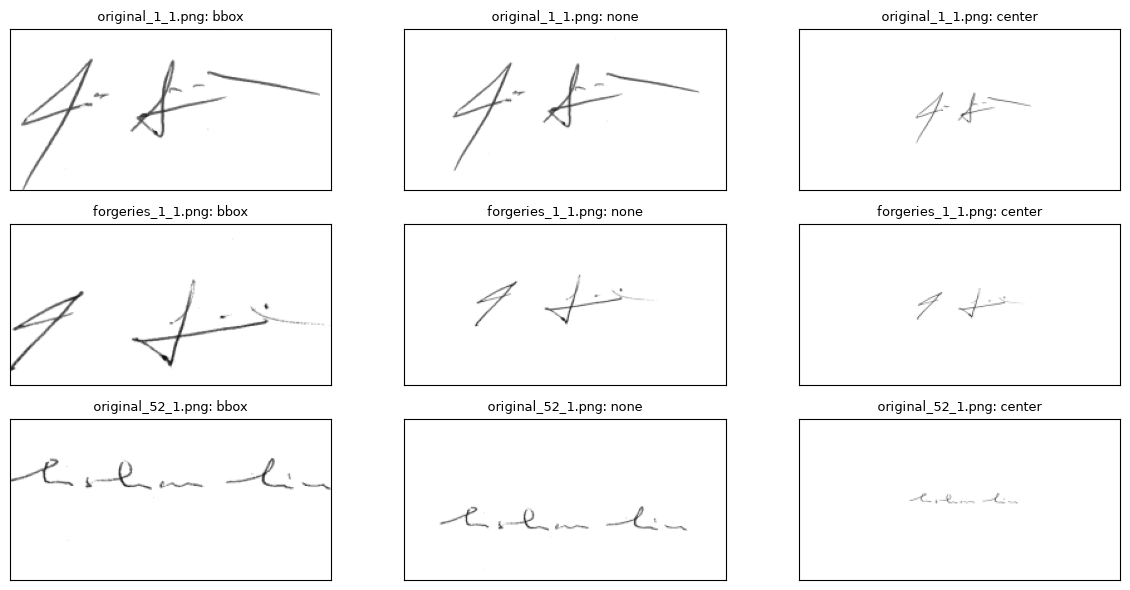

In [2]:
import matplotlib.pyplot as plt
from src.preprocessing import preprocess, CANVAS_SIZE
from src.dataset import image_path

print("tło dla wariantu center:", CANVAS_SIZE)
files = ["original_1_1.png", "forgeries_1_1.png", "original_52_1.png"]
modes = ["bbox", "none", "center"]

fig, axes = plt.subplots(len(files), len(modes), figsize=(12, 6))
for i, name in enumerate(files):
    for j, mode in enumerate(modes):
        axes[i, j].imshow(preprocess(image_path(name), crop=mode), cmap="gray", vmin=0, vmax=255)
        axes[i, j].set_title(f"{name}: {mode}", fontsize=9)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.tight_layout()
plt.show()

In [4]:
if RUN_TRAINING:
    for seed in [1, 2, 3]:
        run_experiment("crop_none", seed, crop="none")
        run_experiment("crop_center", seed, crop="center")

crop_none, seed 1: najlepsza epoka 20, EER test: wykwalifikowane 16.7%, losowe 13.3%
crop_center, seed 1: najlepsza epoka 15, EER test: wykwalifikowane 26.2%, losowe 20.8%
crop_none, seed 2: najlepsza epoka 10, EER test: wykwalifikowane 17.8%, losowe 10.8%
crop_center, seed 2: najlepsza epoka 9, EER test: wykwalifikowane 25.4%, losowe 17.8%
crop_none, seed 3: najlepsza epoka 20, EER test: wykwalifikowane 17.0%, losowe 13.3%
crop_center, seed 3: najlepsza epoka 25, EER test: wykwalifikowane 27.1%, losowe 13.3%


## Podsumowanie wszystkich eksperymentów

In [2]:
with open("../results/experiments.csv", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

groups = defaultdict(list)
for r in rows:
    groups[r["nazwa"]].append(r)

for name, rs in groups.items():
    print(f"{name} ({len(rs)} uruchomień):")
    for key in ["eer_wykwalifikowane", "eer_losowe"]:
        values = np.array([float(r[key]) for r in rs]) * 100
        print(f"  {key}: {values.mean():.1f}% ± {values.std():.1f}  (od {values.min():.1f} do {values.max():.1f})")

stale_pary (3 uruchomień):
  eer_wykwalifikowane: 23.7% ± 3.8  (od 18.8 do 27.9)
  eer_losowe: 16.5% ± 2.8  (od 13.8 do 20.4)
nowe_pary (3 uruchomień):
  eer_wykwalifikowane: 24.6% ± 3.0  (od 21.3 do 28.6)
  eer_losowe: 16.1% ± 1.4  (od 14.2 do 17.5)
aug_geom (3 uruchomień):
  eer_wykwalifikowane: 20.3% ± 1.9  (od 17.9 do 22.5)
  eer_losowe: 11.1% ± 0.6  (od 10.4 do 11.8)
aug_geom_grubosc (3 uruchomień):
  eer_wykwalifikowane: 23.0% ± 2.0  (od 20.4 do 25.3)
  eer_losowe: 13.5% ± 1.4  (od 12.1 do 15.4)
bez_wyrownania_atramentu (3 uruchomień):
  eer_wykwalifikowane: 20.0% ± 1.6  (od 17.8 do 21.7)
  eer_losowe: 12.6% ± 1.3  (od 10.8 do 13.8)
bez_usuwania_tla (3 uruchomień):
  eer_wykwalifikowane: 1.8% ± 0.7  (od 0.8 do 2.5)
  eer_losowe: 14.1% ± 1.3  (od 12.6 do 15.8)
bez_wykw_trening (3 uruchomień):
  eer_wykwalifikowane: 26.4% ± 2.3  (od 24.6 do 29.6)
  eer_losowe: 9.2% ± 1.2  (od 8.3 do 10.8)
bez_wykw_wcale (3 uruchomień):
  eer_wykwalifikowane: 27.8% ± 0.5  (od 27.2 do 28.3)
  eer_los